In [24]:
import pandas as pd
import pickle
import tensorflow as tf
from tensorflow.keras import layers, Model

# Globals

In [25]:
LATENT_DIM = 16
BATCH_SIZE = 2048

# Load dataset

In [26]:
df = pd.read_csv("/kaggle/input/vegemite-manufacturing-data/preprocessed.csv")
with open("/kaggle/input/vegemite-manufacturing-data/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Prepare Dataset

In [27]:
categorical_columns = ["Part", "FFTE Feed solids SP", "TFE Motor speed", "batch"]

tmp = scaler.inverse_transform(df.drop(categorical_columns, axis=1))
tmp = pd.DataFrame(tmp, columns=df.columns[~df.columns.isin(categorical_columns)])
df_clf = pd.concat([df[categorical_columns], tmp], axis=1)

In [28]:
SP_cols = [col for col in df.columns if "SP" in col]

In [29]:
from sklearn.preprocessing import MinMaxScaler

mmscaler = MinMaxScaler()
tmp = mmscaler.fit_transform(df_clf)
df_gan = pd.DataFrame(tmp, columns=df_clf.columns)
df_gan

,Part,FFTE Feed solids SP,TFE Motor speed,batch,FFTE Production solids SP,FFTE Steam pressure SP,TFE Out flow SP,TFE Production solids SP,TFE Vacuum pressure SP,TFE Steam pressure SP,...,TFE Level,TFE Motor current,TFE Out flow PV,TFE Production solids PV,TFE Production solids density,TFE Steam pressure PV,TFE Steam temperature,TFE Tank level,TFE Temperature,TFE Vacuum pressure PV
0,0.0,1.000000,1.0,0.0,0.5225,0.129095,0.464068,0.683673,0.170000,0.924812,...,0.469568,0.429862,0.108665,0.774108,0.741176,0.740085,0.663404,0.390195,0.333333,0.115178
1,0.0,1.000000,1.0,0.0,0.5225,0.129095,0.464068,0.683673,0.170000,0.924812,...,0.463947,0.403407,0.104711,0.785736,0.847059,0.738191,0.663404,0.388423,0.314815,0.111381
2,0.0,1.000000,1.0,0.0,0.5225,0.136905,0.464068,0.683673,0.170000,0.924812,...,0.463947,0.377339,0.127997,0.747696,0.847059,0.740085,0.610316,0.381926,0.296296,0.115178
3,0.0,1.000000,1.0,0.0,0.5225,0.136905,0.464068,0.683673,0.171852,0.924812,...,0.425179,0.403923,0.076385,0.775902,0.847059,0.740085,0.610316,0.359953,0.333333,0.115178
4,0.5,1.000000,1.0,0.0,0.0000,0.095238,0.537575,0.663265,0.166667,0.887218,...,0.126769,0.310492,0.038737,0.282675,0.694118,0.709779,0.775602,0.026226,0.351852,0.204303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37252,1.0,1.000000,1.0,1.0,1.0000,0.142857,0.636780,0.782225,0.479001,0.887218,...,0.437294,0.368177,0.152044,0.847405,0.905882,0.709779,0.752824,0.796338,0.500000,0.297226
37253,1.0,1.000000,1.0,1.0,1.0000,0.147900,0.764775,0.702523,0.275828,0.887218,...,0.454098,0.376742,0.138351,0.780377,0.894118,0.710068,0.695307,0.796482,0.407407,0.193490
37254,0.0,1.000000,1.0,1.0,0.8675,0.145343,0.571299,0.696457,0.674565,0.887218,...,0.465873,0.394682,0.110738,0.796114,0.864772,0.708963,0.854925,0.505478,0.537037,0.404078
37255,0.5,0.000000,0.0,1.0,0.6687,0.166737,0.592400,0.168969,0.722222,0.863169,...,0.479289,0.123463,0.421245,0.349598,0.456415,0.004660,0.223618,0.824479,0.129630,0.986053


In [30]:
X_gan = df_gan[df_gan["batch"] == 1.0].reset_index(drop=True)
y_gan = X_gan[SP_cols]
X_gan = X_gan.drop(SP_cols + ["batch"], axis=1)

In [31]:
y_clf = df_clf.pop("batch")

## Split train and test

In [32]:
from sklearn.model_selection import train_test_split

X_gan_train, X_gan_test, y_gan_train, y_gan_test = train_test_split(X_gan, y_gan, random_state=42, test_size=0.2)
X_clf, X_test_clf, y_clf, y_test_clf = train_test_split(df_clf, y_clf, random_state=42, test_size=0.2)
X_gan_test.reset_index(inplace=True, drop=True)
y_gan_test.reset_index(inplace=True, drop=True)

In [33]:
X_gan_cvt = tf.cast(X_gan_train, tf.float32)
y_gan_cvt = tf.cast(y_gan_train, tf.float32)

ds = tf.data.Dataset.from_tensor_slices((X_gan_cvt, y_gan_cvt))
test_ds = tf.data.Dataset.from_tensor_slices((X_gan_test, y_gan_test))

ds = ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [34]:
sensors_shape = X_gan.shape[1]
settings_shape = len(SP_cols)

# Train RandomForestClassifier for evaluation

In [35]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
clf.fit(X_clf, y_clf)
print(f"Training accuracy: {clf.score(X_clf, y_clf)}")
print(f"Test accuracy: {clf.score(X_test_clf, y_test_clf)}")

Training accuracy: 0.958161382318403
Test accuracy: 0.9386741814278046


# Build Model

In [36]:
def generator_model():
    sensors_input = layers.Input(shape=(sensors_shape,))
    noise_input = layers.Input(shape=(LATENT_DIM,))
    
    x = layers.Concatenate()([sensors_input, noise_input])
    x = layers.Dense(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dense(16)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    out = layers.Dense(settings_shape, activation="sigmoid")(x)
    return Model(inputs=[noise_input, sensors_input], outputs=out, name="Generator")

generator = generator_model()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 23)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_5             │ (None, 16)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 39)             │              0 │ input_layer_4[0][0],   │
│ (Concatenate)             │                        │                │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 32)             │          1,280 │ concatenate_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 32)             │            128 │ dense_6[0][0]          │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_4 (LeakyReLU) │ (None, 32)             │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 16)             │            528 │ leaky_re_lu_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 16)             │             64 │ dense_7[0][0]          │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_5 (LeakyReLU) │ (None, 16)             │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 7)              │            119 │ leaky_re_lu_5[0][0]    │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,119 (8.28 KB)

 Trainable params: 2,023 (7.90 KB)

 Non-trainable params: 96 (384.00 B)

In [37]:
def discriminator_model():
    sensors_input = layers.Input(shape=(sensors_shape,))
    settings_input = layers.Input(shape=(settings_shape,))
    
    x = layers.Concatenate()([sensors_input, settings_input])
    x = layers.Dense(32)(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dense(16)(x)
    x = layers.LeakyReLU()(x)

    out = layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inputs=[settings_input, sensors_input], outputs=out)

discriminator = discriminator_model()
discriminator.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 23)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_7             │ (None, 7)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_3             │ (None, 30)             │              0 │ input_layer_6[0][0],   │
│ (Concatenate)             │                        │                │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)           │ (None, 32)             │            992 │ concatenate_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_6 (LeakyReLU) │ (None, 32)             │              0 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 16)             │            528 │ leaky_re_lu_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_7 (LeakyReLU) │ (None, 16)             │              0 │ dense_10[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 1)              │             17 │ leaky_re_lu_7[0][0]    │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

# Optimizers

In [38]:
g_optim = tf.keras.optimizers.Adam(1e-5)
d_optim = tf.keras.optimizers.Adam(1e-5)

# Losses

In [39]:
bce = tf.keras.losses.BinaryCrossentropy()

In [40]:
def discriminator_loss(real_output, fake_output):
    real_loss = bce(tf.ones_like(real_output), real_output)
    fake_loss = bce(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss
def generator_loss(fake_output):
    return bce(tf.ones_like(fake_output), fake_output)

# Training

In [41]:
@tf.function
def generator_step(sensors_data):
    noise = tf.random.normal([tf.shape(sensors_data)[0], LATENT_DIM])

    with tf.GradientTape() as gen_tape:
        generated_settings = generator([noise, sensors_data], training=True)
        fake_output = discriminator([generated_settings, sensors_data], training=True)
        gen_loss = generator_loss(fake_output)

    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    g_optim.apply_gradients(zip(gen_grads, generator.trainable_variables))

    return gen_loss

@tf.function
def discriminator_step(sensors_data, actual_settings):
    noise = tf.random.normal([tf.shape(sensors_data)[0], LATENT_DIM])
    generated_settings = generator([noise, sensors_data], training=True)

    with tf.GradientTape() as disc_tape:
        real_output = discriminator([actual_settings, sensors_data], training=True)
        fake_output = discriminator([generated_settings, sensors_data], training=True)
        disc_loss = discriminator_loss(real_output, fake_output)

    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    d_optim.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return disc_loss


In [42]:
from tqdm import tqdm
checkpoints = [100, 1000, 2500, 5000]
gen_losses = []
disc_losses = []

for epoch in range(5000):
    for batch in ds:
        sensors_data = batch[0] # (32, 23)
        sensors_data = tf.convert_to_tensor(sensors_data, dtype=tf.float32)
        actual_settings = batch[1] # (32, 7)
        actual_settings = tf.convert_to_tensor(actual_settings, dtype=tf.float32)
        
        for _ in range(2):
            gen_loss = generator_step(sensors_data)
        gen_losses.append(gen_loss)
        disc_loss = discriminator_step(sensors_data, actual_settings)
        disc_losses.append(disc_loss)
    if (epoch+1 in checkpoints):
        print(f"Epoch: {epoch+1}\nGenerator loss: {gen_loss}\nDiscriminator loss: {disc_loss}\n\n")

Epoch: 100
Generator loss: 0.9561824798583984
Discriminator loss: 1.5078113079071045


Epoch: 1000
Generator loss: 0.8176394104957581
Discriminator loss: 1.1711004972457886


Epoch: 2500
Generator loss: 0.7335364818572998
Discriminator loss: 1.3389313220977783


Epoch: 5000
Generator loss: 0.7009517550468445
Discriminator loss: 1.3771418333053589




# Evaluation

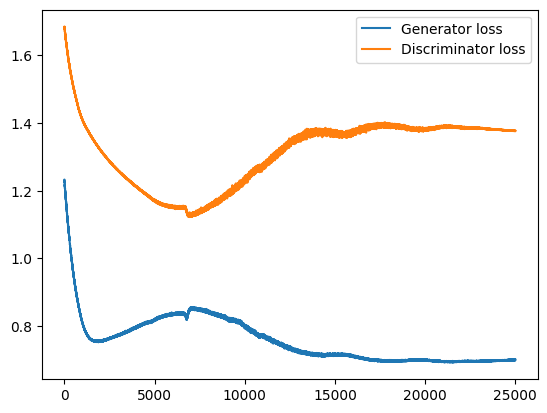

In [43]:
import matplotlib.pyplot as plt

plt.plot(gen_losses, label="Generator loss")
plt.plot(disc_losses, label="Discriminator loss")
plt.legend()
plt.show()

In [44]:
import pickle

scaler_path = "/kaggle/input/vegemite-manufacturing-data/scaler.pkl"
with open(scaler_path, "rb") as f:
    scaler = pickle.load(f)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [91]:
test_preds = []
train_preds = []

for batch in test_ds:
    sensors = batch[0]
    actual_settings = batch[1]
    noise = tf.random.normal([sensors.shape[0], LATENT_DIM])
    test_preds.append(generator([noise, sensors]))
    
for batch in ds:
    sensors = batch[0]
    actual_settings = batch[1]
    noise = tf.random.normal([sensors.shape[0], LATENT_DIM])
    train_preds.append(generator([noise, sensors]))


### Format 

In [92]:
preds_numpy = tf.concat(test_preds, axis=0).numpy()
test_preds_df = pd.DataFrame(preds_numpy, columns=SP_cols)
test_preds_df = pd.concat([test_preds_df, X_gan_test.reset_index(drop=True)], axis=1)
preds_numpy = tf.concat(train_preds, axis=0).numpy()
train_preds_df = pd.DataFrame(preds_numpy, columns=SP_cols)
train_preds_df = pd.concat([train_preds_df, X_gan_train.reset_index(drop=True)], axis=1)

In [93]:
orig_columns_order = df_gan.drop("batch", axis=1).columns

In [94]:
test_preds_df = test_preds_df[orig_columns_order]
train_preds_df = train_preds_df[orig_columns_order]

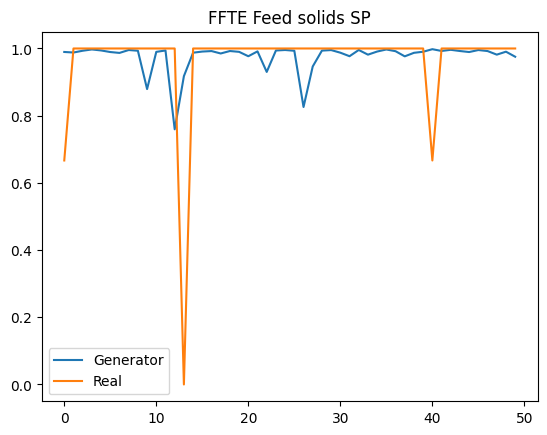

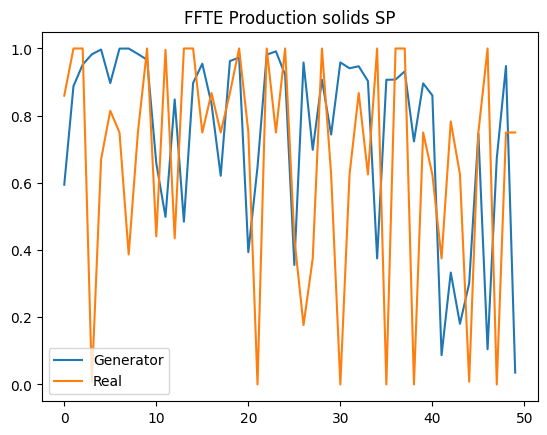

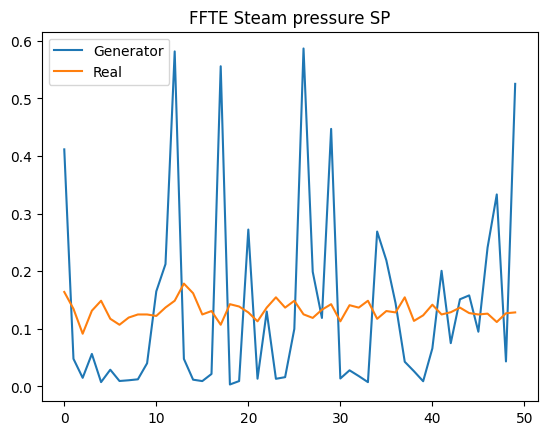

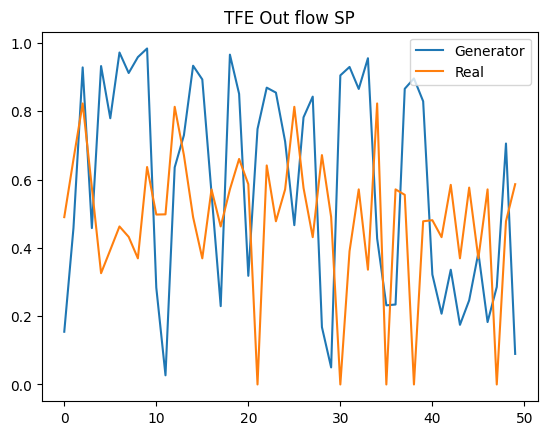

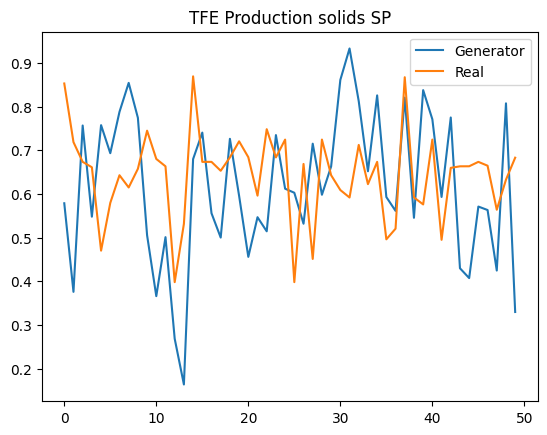

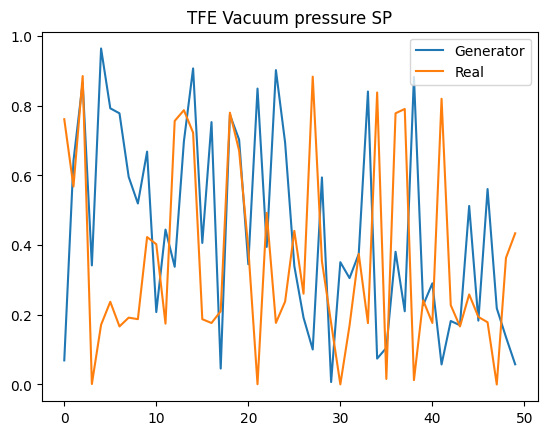

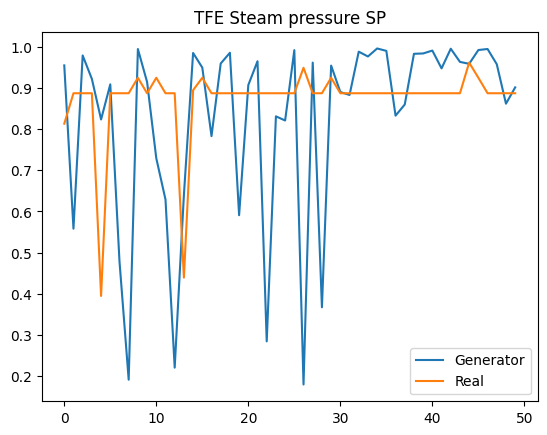

Training dataset


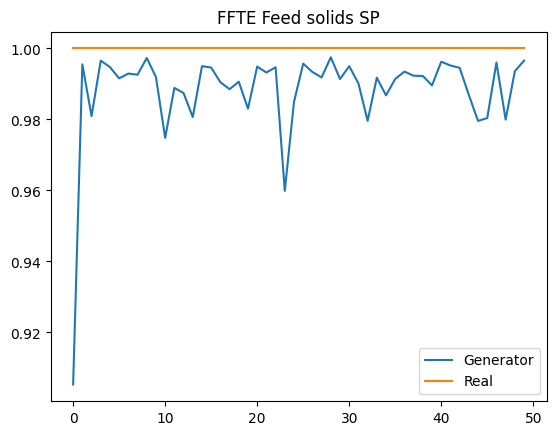

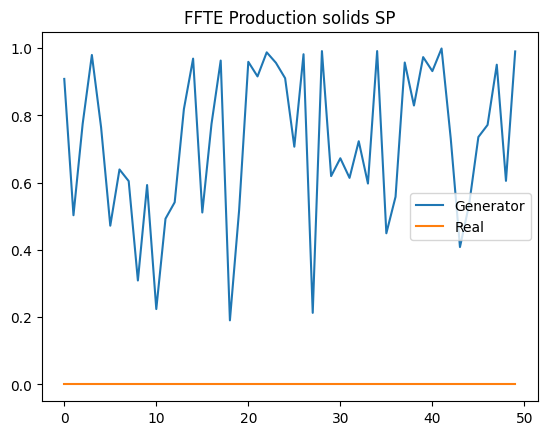

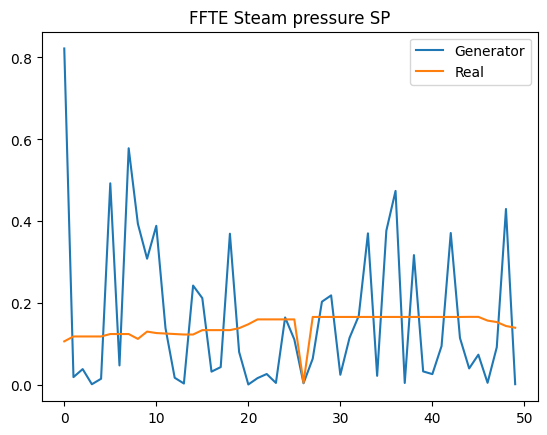

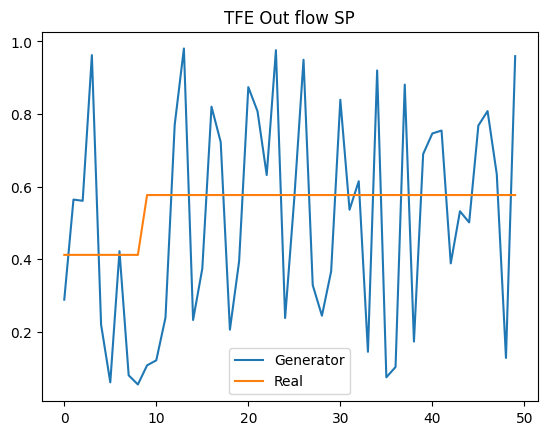

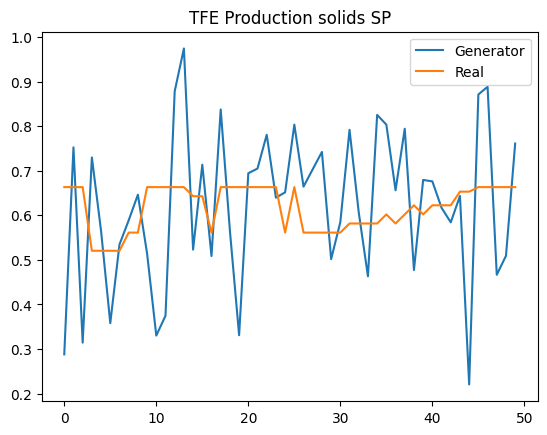

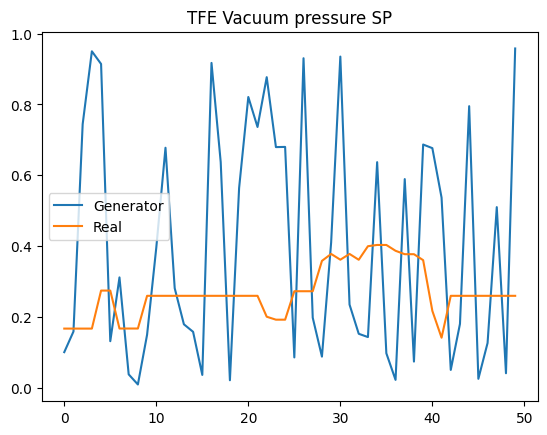

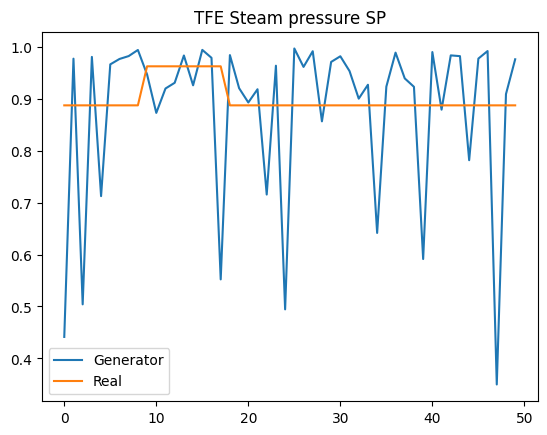

In [69]:
for i, col in enumerate(SP_cols):
    plt.title(col)
    plt.plot(test_preds_df[col][:50], label="Generator")
    plt.plot(y_gan_test[col][:50], label="Real")
    plt.legend()
    plt.show()

print("Training dataset")
for i, col in enumerate(SP_cols):
    plt.title(col)
    plt.plot(train_preds_df[col][:50], label="Generator")
    plt.plot(y_gan[col][:50], label="Real")
    plt.legend()
    plt.show()

In [95]:
orig_data_train = pd.concat([X_gan_train, y_gan_train], axis=1)
orig_data_test = pd.concat([X_gan_test, y_gan_test], axis=1)

orig_data_train = orig_data_train[orig_columns_order]
orig_data_test = orig_data_test[orig_columns_order]

In [117]:
y_true_train = clf.predict(orig_data_train)
y_pred_train = clf.predict(train_preds_df)
y_true_test = clf.predict(orig_data_test)
y_pred_test = clf.predict(test_preds_df)

In [115]:
y_true_train

array([1, 1, 1, ..., 1, 2, 1])

In [118]:
y_pred_train

array([1, 1, 1, ..., 1, 2, 1])

In [120]:
from sklearn.metrics import accuracy_score

print("Accuracy for training dataset: ", accuracy_score(y_true_train, y_pred_train))
print("Accuracy for test dataset: ", accuracy_score(y_true_test, y_pred_test))

Accuracy for training dataset:  1.0
Accuracy for test dataset:  1.0
